In [1]:
import joblib
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

sns.set_style("whitegrid")

In [2]:
model = joblib.load("../ml/best_model.pkl")

In [3]:
X_test = joblib.load("../data/processed/X_test.pkl")

y_test = joblib.load("../data/processed/y_test.pkl")

In [4]:
print(X_test.shape)
print(y_test.shape)

(61503, 225)
(61503,)


In [5]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

d:\Creditwise-Ai\creditwise_ai\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Creditwise-Ai\creditwise_ai\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [6]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[40151 16387]
 [ 1609  3356]]


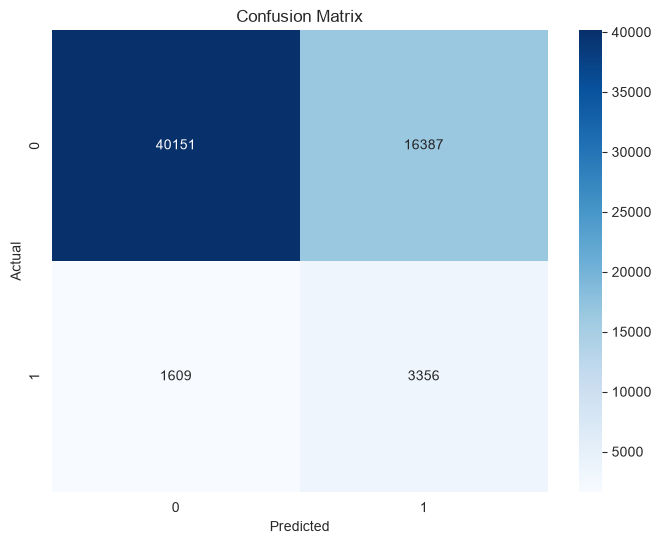

In [7]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [8]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.68      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.54     61503
weighted avg       0.90      0.71      0.77     61503



In [9]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

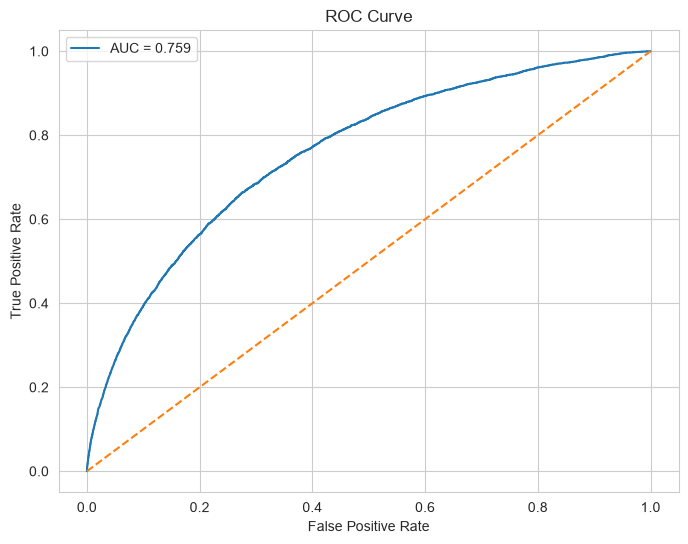

In [10]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [11]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

ap_score = average_precision_score(
    y_test,
    y_prob
)

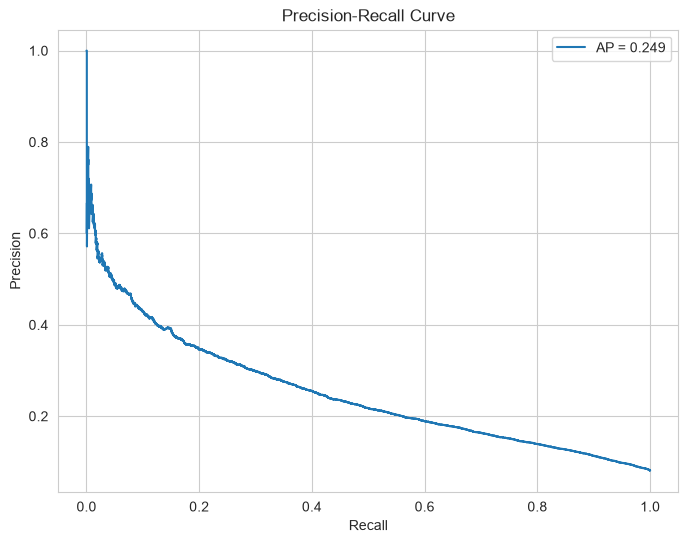

In [12]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap_score:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

## Why Precision-Recall Matters

This dataset is highly imbalanced because most customers repay their loans.

ROC-AUC measures overall ranking performance, but it can be overly optimistic for imbalanced datasets.

Precision-Recall curves focus specifically on the minority class (loan defaults).

Important questions:

- How many defaulters can the model identify?
- How many false alarms occur?

For credit scoring, recall is prioritized because missing a defaulter is more costly than incorrectly flagging a safe customer.

In [13]:
preprocessor = joblib.load("../ml/preprocessor.pkl")

In [14]:
importance = model.feature_importances_

feature_names = preprocessor.get_feature_names_out()

In [15]:
print(len(feature_names))
print(len(importance))

225
225


In [16]:
feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

In [17]:
feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

feature_df.head(20)

,Feature,Importance
27,num__EXT_SOURCE_1,232
29,num__EXT_SOURCE_3,205
3,num__AMT_CREDIT,187
28,num__EXT_SOURCE_2,187
7,num__DAYS_BIRTH,178
4,num__AMT_ANNUITY,150
8,num__DAYS_EMPLOYED,131
10,num__DAYS_ID_PUBLISH,124
5,num__AMT_GOODS_PRICE,117
9,num__DAYS_REGISTRATION,76


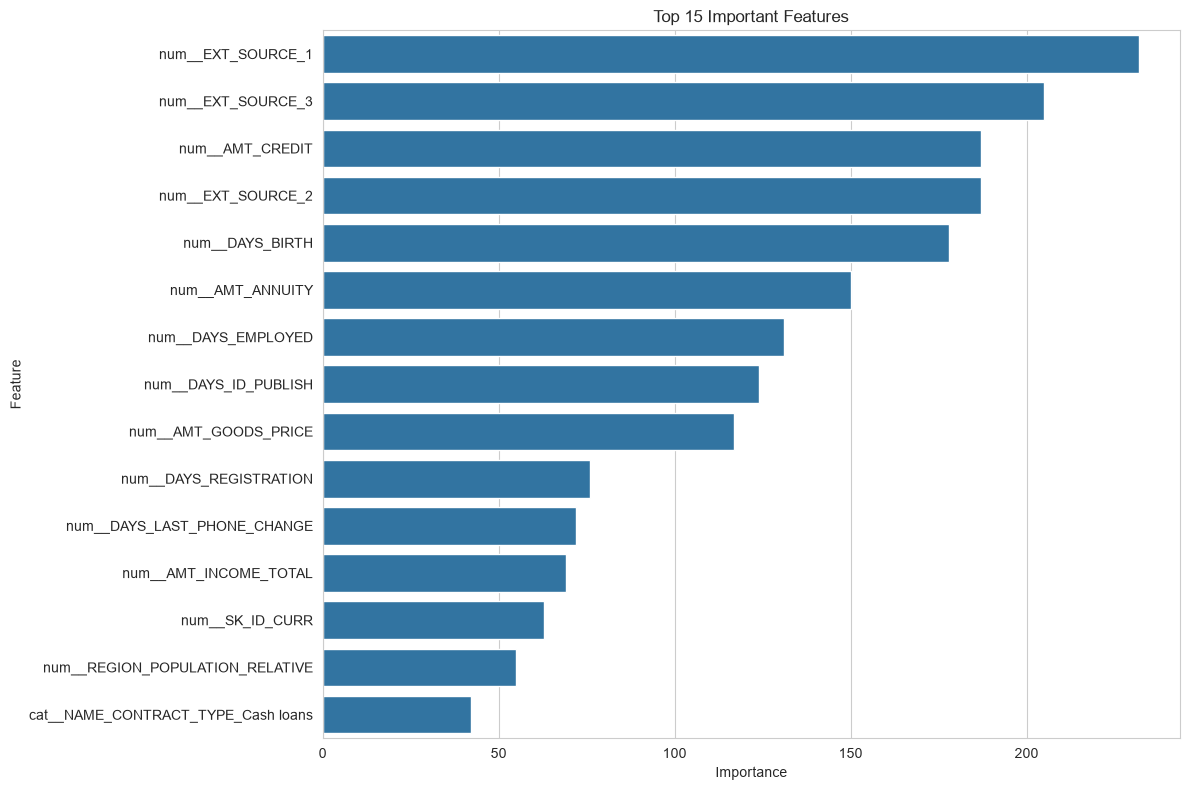

In [18]:
top_features = feature_df.head(15)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.show()

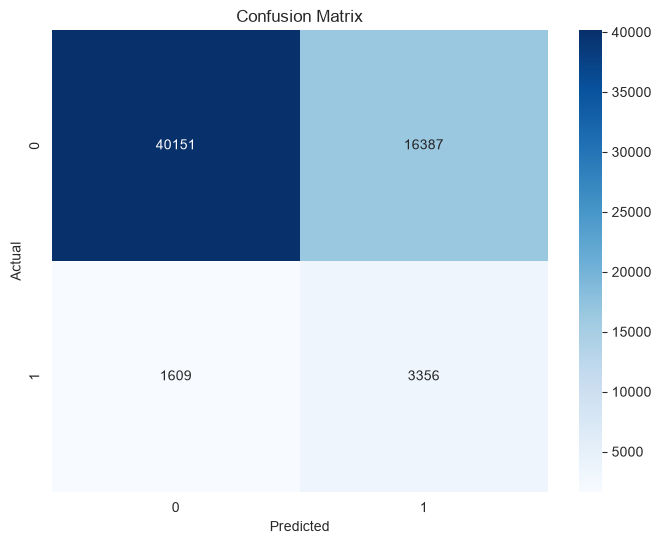

In [20]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../reports/figures/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

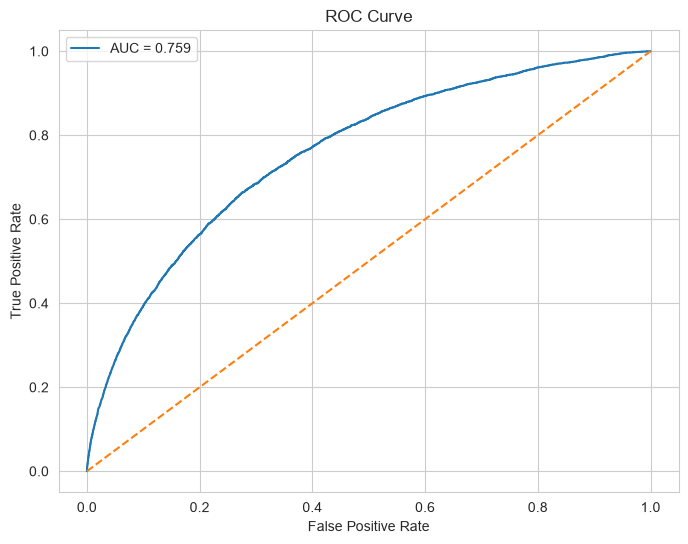

In [21]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig(
    "../reports/figures/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

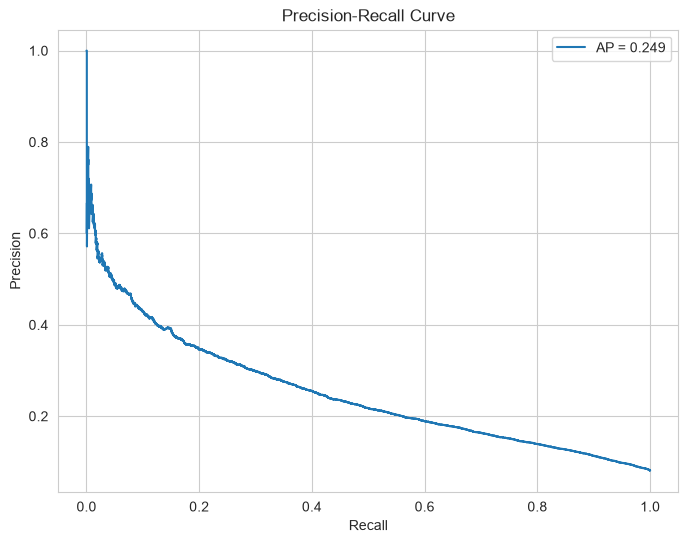

In [22]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"AP = {ap_score:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.savefig(
    "../reports/figures/precision_recall_curve.png",
    bbox_inches="tight"
)

plt.show()

In [23]:
feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=False
)

feature_df.head(20)

,Feature,Importance
27,num__EXT_SOURCE_1,232
29,num__EXT_SOURCE_3,205
3,num__AMT_CREDIT,187
28,num__EXT_SOURCE_2,187
7,num__DAYS_BIRTH,178
4,num__AMT_ANNUITY,150
8,num__DAYS_EMPLOYED,131
10,num__DAYS_ID_PUBLISH,124
5,num__AMT_GOODS_PRICE,117
9,num__DAYS_REGISTRATION,76


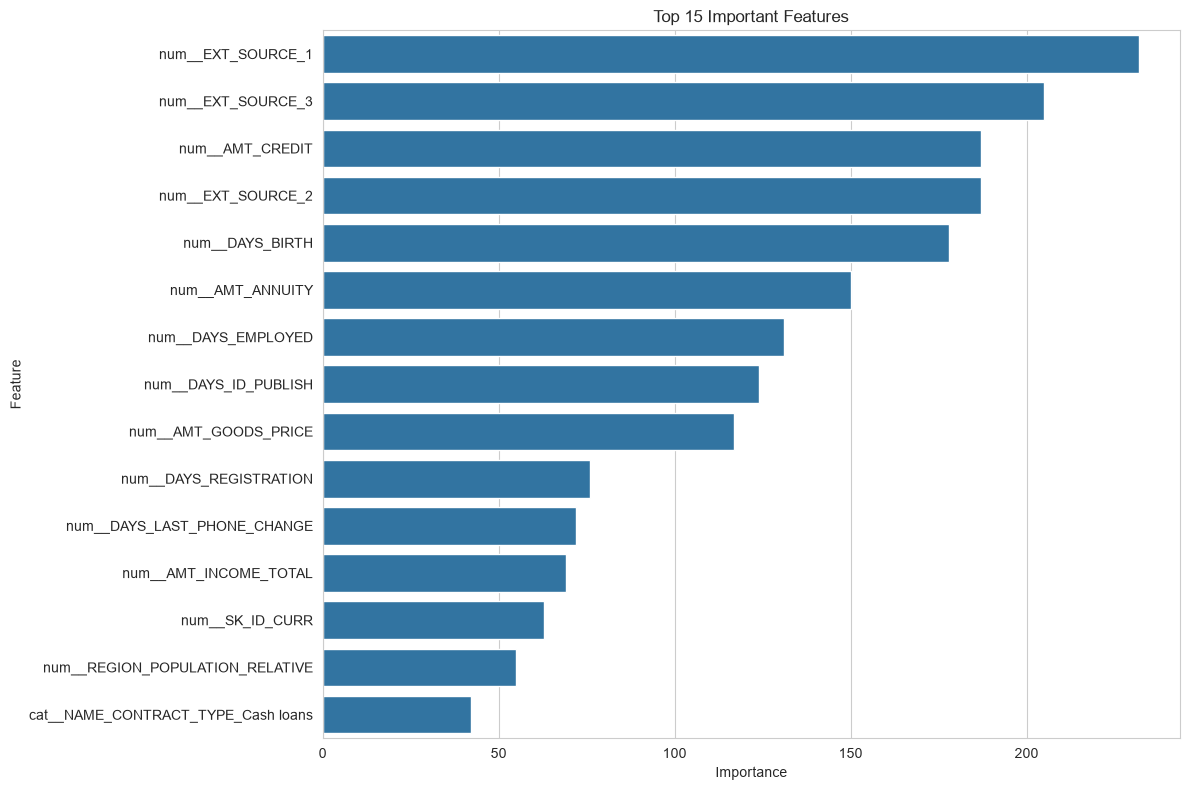

In [24]:
top_features = feature_df.head(15)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.savefig(
    "../reports/figures/feature_importance.png",
    bbox_inches="tight"
)

plt.show()